# Scan-rescan stability: upper vs lower acquisitions

Analyzes lesion volume scan-rescan stability (`volume_stability.csv`, merged by `aggregate_volume_stability.py`) split by `acquisition` (`upper` / `lower`) and by `run` (model checkpoint / prediction date).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_rows", 200)

In [2]:
DATA_PATH = "../../output_eval_upper_lower_tta/merged.csv"

df = pd.read_csv(DATA_PATH)
df["case"] = df["subject"] + "_" + df["session"]
df.head()

,subject,session,model,volume_run1_mm3,volume_run2_mm3,mean_volume_mm3,abs_vol_diff_mm3,cv_percent,run,acquisition,case
0,sub-001,ses-M0,r20250909,0.000000,0.000000,0.000000,0.000000,0.000000,r20250909,lower,sub-001_ses-M0
1,sub-002,ses-M0,r20250909,0.000000,0.000000,0.000000,0.000000,0.000000,r20250909,lower,sub-002_ses-M0
2,sub-004,ses-M0,r20250909,125.640525,202.792938,164.216731,77.152413,33.221337,r20250909,lower,sub-004_ses-M0
3,sub-005,ses-M0,r20250909,167.436935,181.099789,174.268362,13.662854,5.543804,r20250909,lower,sub-005_ses-M0
4,sub-001,ses-M0,r20250909,8.840269,2.410982,5.625626,6.429286,80.812204,r20250909,upper,sub-001_ses-M0


## Overview

In [3]:
print(f"rows: {len(df)}")
print(f"subjects: {sorted(df['subject'].unique())}")
print(f"runs: {sorted(df['run'].unique())}")
print(f"acquisitions: {sorted(df['acquisition'].unique())}")
df.groupby(["run", "acquisition"]).size().rename("n_cases").to_frame()

rows: 27
subjects: ['sub-001', 'sub-002', 'sub-003', 'sub-004', 'sub-005']
runs: ['r20250909', 'r20260629', 'r20260703']
acquisitions: ['lower', 'upper']


n_cases
run       acquisition         
r20250909 lower              4
          upper              5
r20260629 lower              4
          upper              5
r20260703 lower              4
          upper              5

## Summary statistics per run x acquisition

Coefficient of variation (`cv_percent`) and mean lesion volume, run-1 vs run-2 scan-rescan pair.

In [4]:
summary = df.groupby(["run", "acquisition"]).agg(
    n=("cv_percent", "size"),
    cv_mean=("cv_percent", "mean"),
    cv_std=("cv_percent", "std"),
    cv_median=("cv_percent", "median"),
    mean_volume_mm3=("mean_volume_mm3", "mean"),
    abs_vol_diff_mm3=("abs_vol_diff_mm3", "mean"),
)
summary

n    cv_mean     cv_std  cv_median  mean_volume_mm3  \
run       acquisition                                                        
r20250909 lower        4   9.691285  15.902903   2.771902        84.621273   
          upper        5  49.279618  60.550437  14.577009       118.382571   
r20260629 lower        4  42.615920  43.459574  36.112879       348.855841   
          upper        5  58.880897  72.034689  14.268971       136.274115   
r20260703 lower        4  69.920958  53.241626  60.493287       164.850960   
          upper        5  33.456052  60.998328   4.176556       127.326689   

                       abs_vol_diff_mm3  
run       acquisition                    
r20250909 lower               22.703817  
          upper               13.984186  
r20260629 lower              374.104190  
          upper               25.663574  
r20260703 lower              107.221770  
          upper               20.305834

## CV distribution: upper vs lower, per run

/var/folders/_2/l62mvrbx76l6nx_408gf05140000gn/T/ipykernel_33040/2960956974.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["upper", "lower"], showmeans=True)
/var/folders/_2/l62mvrbx76l6nx_408gf05140000gn/T/ipykernel_33040/2960956974.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["upper", "lower"], showmeans=True)
/var/folders/_2/l62mvrbx76l6nx_408gf05140000gn/T/ipykernel_33040/2960956974.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["upper", "lower"], showmeans=True)


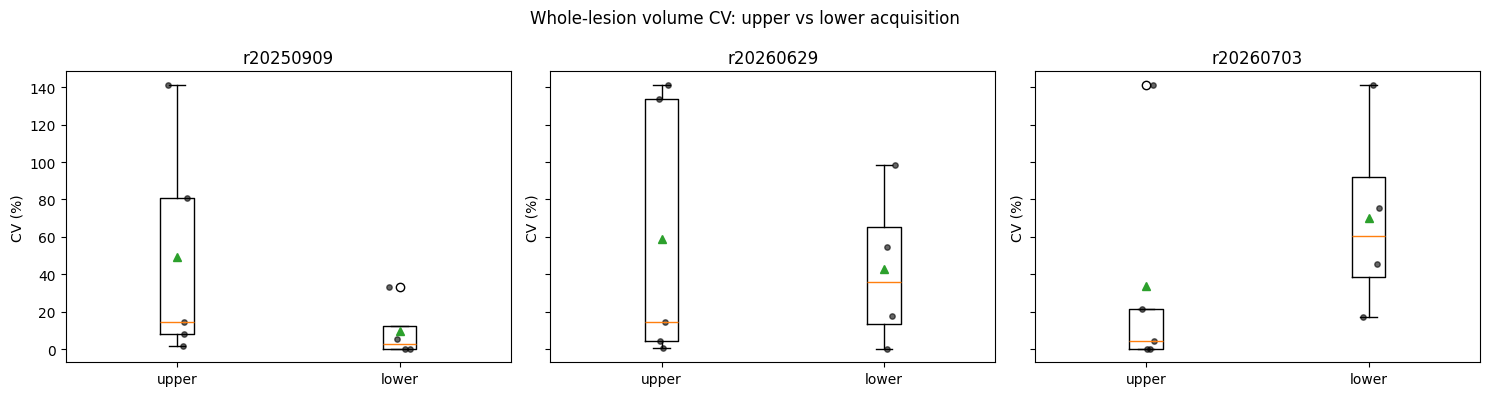

In [5]:
runs = sorted(df["run"].unique())
fig, axes = plt.subplots(1, len(runs), figsize=(5 * len(runs), 4), sharey=True)
if len(runs) == 1:
    axes = [axes]

for ax, run in zip(axes, runs):
    sub = df[df["run"] == run]
    data = [sub[sub["acquisition"] == acq]["cv_percent"].dropna() for acq in ["upper", "lower"]]
    ax.boxplot(data, labels=["upper", "lower"], showmeans=True)
    for i, acq in enumerate(["upper", "lower"]):
        y = sub[sub["acquisition"] == acq]["cv_percent"].dropna()
        ax.scatter(np.full(len(y), i + 1) + np.random.uniform(-0.05, 0.05, len(y)), y, alpha=0.6, color="black", s=15)
    ax.set_title(run)
    ax.set_ylabel("CV (%)")

fig.suptitle("Whole-lesion volume CV: upper vs lower acquisition")
fig.tight_layout()
plt.show()

## Per-subject paired comparison

Same subject/session, CV in `upper` vs `lower`, one line per case, faceted by run.

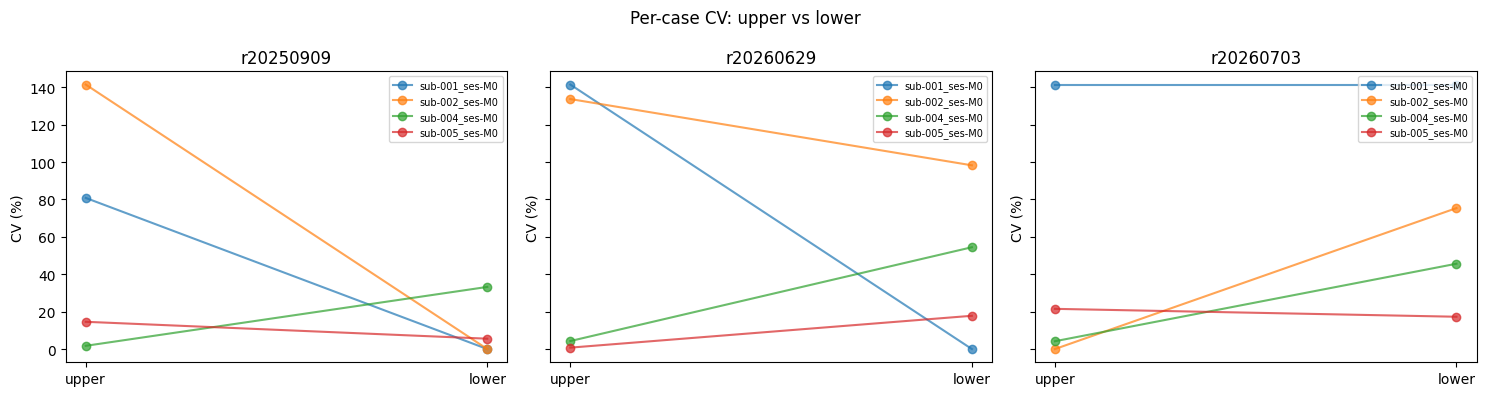

In [6]:
fig, axes = plt.subplots(1, len(runs), figsize=(5 * len(runs), 4), sharey=True)
if len(runs) == 1:
    axes = [axes]

for ax, run in zip(axes, runs):
    pivot = df[df["run"] == run].pivot_table(index="case", columns="acquisition", values="cv_percent")
    for case, row in pivot.dropna().iterrows():
        ax.plot(["upper", "lower"], [row["upper"], row["lower"]], marker="o", alpha=0.7, label=case)
    ax.set_title(run)
    ax.set_ylabel("CV (%)")
    ax.legend(fontsize=7, loc="upper right")

fig.suptitle("Per-case CV: upper vs lower")
fig.tight_layout()
plt.show()

## Run-1 vs run-2 volume agreement

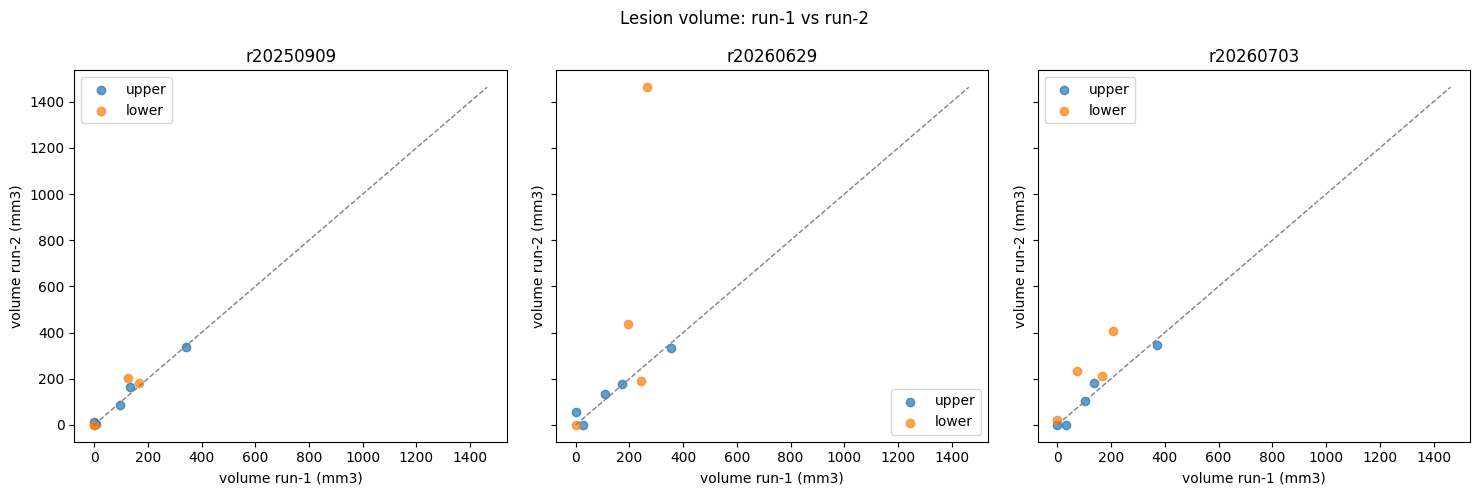

In [7]:
fig, axes = plt.subplots(1, len(runs), figsize=(5 * len(runs), 5), sharex=True, sharey=True)
if len(runs) == 1:
    axes = [axes]

colors = {"upper": "tab:blue", "lower": "tab:orange"}
max_vol = df[["volume_run1_mm3", "volume_run2_mm3"]].max().max()

for ax, run in zip(axes, runs):
    sub = df[df["run"] == run]
    for acq in ["upper", "lower"]:
        s = sub[sub["acquisition"] == acq]
        ax.scatter(s["volume_run1_mm3"], s["volume_run2_mm3"], label=acq, color=colors[acq], alpha=0.7)
    ax.plot([0, max_vol], [0, max_vol], linestyle="--", color="gray", linewidth=1)
    ax.set_xlabel("volume run-1 (mm3)")
    ax.set_ylabel("volume run-2 (mm3)")
    ax.set_title(run)
    ax.legend()

fig.suptitle("Lesion volume: run-1 vs run-2")
fig.tight_layout()
plt.show()

## Zero / near-zero lesion volume cases

Cases where the mean predicted lesion volume across run-1/run-2 is (near) zero, i.e. no lesion detected in that acquisition.

In [8]:
zero_cases = df[df["mean_volume_mm3"] < 1e-6][["run", "acquisition", "case", "volume_run1_mm3", "volume_run2_mm3"]]
zero_cases

,run,acquisition,case,volume_run1_mm3,volume_run2_mm3
0,r20250909,lower,sub-001_ses-M0,0.0,0.0
1,r20250909,lower,sub-002_ses-M0,0.0,0.0
9,r20260629,lower,sub-001_ses-M0,0.0,0.0
23,r20260703,upper,sub-002_ses-M0,0.0,0.0


## Statistical comparison: upper vs lower CV (paired by case, per run)

In [9]:
for run in runs:
    pivot = df[df["run"] == run].pivot_table(index="case", columns="acquisition", values="cv_percent").dropna()
    if len(pivot) < 2:
        print(f"{run}: not enough paired cases (n={len(pivot)})")
        continue
    stat, p = stats.wilcoxon(pivot["upper"], pivot["lower"])
    print(f"{run} (n={len(pivot)}): Wilcoxon statistic={stat:.4f}, p={p:.4g}")

r20250909 (n=4): Wilcoxon statistic=2.0000, p=0.375
r20260629 (n=4): Wilcoxon statistic=4.0000, p=0.875
r20260703 (n=4): Wilcoxon statistic=1.0000, p=0.5
